# Loss functions

> A set of custom loss functions

In [ ]:
#| default_exp losses

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export

# =================================
# Scientific
# =================================
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# =================================
# PyTorch
# =================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import sigmoid
from torch.nn import CrossEntropyLoss

# =================================
# MONAI
# =================================
from monai.losses import SSIMLoss

# =================================
# fastai
# =================================
from fastai.vision.all import (
    Any,
    CrossEntropyLossFlat,
    mae,
    mse,
    test_eq,
    test_is,
)

# =================================
# bioMONAI
# =================================
from bioMONAI.utils import *

In [ ]:
#| export

def MSELoss(
    inp: Any,
    targ: Any
    ) -> torchTensor:
    
    return mse(inp, targ)


In [ ]:
#| export
def L1Loss(
    inp: Any,
    targ: Any
    ) -> torchTensor:
    
    return mae(inp, targ)

In [ ]:
show_doc(SSIMLoss)

---

### SSIMLoss

```python

def SSIMLoss(
    spatial_dims:int, data_range:float=1.0, kernel_type:KernelType | str=gaussian, win_size:int | Sequence[int]=11,
    kernel_sigma:float | Sequence[float]=1.5, k1:float=0.01, k2:float=0.03, reduction:LossReduction | str=mean
):


```

*Compute the loss function based on the Structural Similarity Index Measure (SSIM) Metric.*

For more info, visit
    https://vicuesoft.com/glossary/term/ssim-ms-ssim/

SSIM reference paper:
    Wang, Zhou, et al. "Image quality assessment: from error visibility to structural
    similarity." IEEE transactions on image processing 13.4 (2004): 600-612.

### Combined Losses

In [ ]:
#| export

class CombinedLoss:
    """
    CombinedLoss computes a weighted combination of SSIM, MSE, and MAE losses.

    This class allows for the combination of three different loss functions:
    Structural Similarity Index (SSIM), Mean Squared Error (MSE), and Mean Absolute Error (MAE).
    The weights for MSE and MAE can be adjusted, and the weight for SSIM is automatically 
    calculated as the remaining weight.
    
    CombinedLoss reference paper:
    Shah, Z. H., Müller, M., Hammer, B., Huser, T., & Schenck, W. (2022, July). 
    Impact of different loss functions on denoising of microscopic images. 
    In 2022 International Joint Conference on Neural Networks (IJCNN) (pp. 1-10). IEEE.
    """
    def __init__(self, spatial_dims=2,  # Number of spatial dimensions (2 for 2D images, 3 for 3D images)
                 mse_weight=0.33,       # Weight for the MSE loss component
                 mae_weight=0.33,       # Weight for the MAE loss component
                 ):
        store_attr()
        self.SSIM_loss = SSIMLoss(spatial_dims=spatial_dims)
        self.MSE_loss = nn.MSELoss()
        self.MAE_loss = nn.L1Loss()
        
    def __call__(self, pred, targ):
        """
        Compute the combined loss.
        """
        return (1 - self.mse_weight - self.mae_weight) * self.SSIM_loss(pred, targ) + self.mse_weight * self.MSE_loss(pred, targ) + self.mae_weight * self.MAE_loss(pred, targ)
        

In [ ]:
#| export
class MSSSIMLoss(torch.nn.Module):
    """
    Multi-Scale Structural Similarity (MSSSIM) Loss using MONAI's SSIMLoss as the base.
    """
    def __init__(self, spatial_dims=2,      # Number of spatial dimensions (2 for 2D images, 3 for 3D images).
                 window_size: int = 8,      # Size of the Gaussian filter for SSIM.
                 sigma: float = 1.5,        # Standard deviation of the Gaussian filter.
                 reduction: str = "mean",   # Specifies the reduction to apply to the output ('mean', 'sum', or 'none').
                 levels: int = 3,           # Number of scales to use for MS-SSIM.
                 weights=None,              # Weights to apply to each scale. If None, default values are used.
                 ):
        super(MSSSIMLoss, self).__init__()
        self.ssim = SSIMLoss(spatial_dims, win_size=window_size, kernel_sigma=sigma, reduction="none")
        self.levels = levels
        if weights is None:
            # Default weights for 5 levels, typically used in MS-SSIM
            self.weights = torch.FloatTensor([0.0448, 0.2856, 0.3001, 0.2363, 0.1333])
        else:
            self.weights = torch.FloatTensor(weights)
        self.weights = self.weights[:levels]
        self.reduction = reduction
        self.spatial_dims = spatial_dims

    def forward(self, x, y):
        # Ensure input tensors are the same size
        if x.size() != y.size():
            raise ValueError("Input images must have the same dimensions.")
        
        # Make sure the weights match the number of levels
        if len(self.weights) != self.levels:
            raise ValueError(f"Number of weights ({len(self.weights)}) must match the number of levels ({self.levels}).")
        
        msssim_values = []
        for i in range(self.levels):
            # Compute SSIM at this scale
            ssim_value = self.ssim(x, y)
            msssim_values.append(ssim_value * self.weights[i])

            # Downsample images for the next scale, except at the last scale
            if i < self.levels - 1:
                pool = F.avg_pool2d if self.spatial_dims == 2 else F.avg_pool3d
                x = pool(x, kernel_size=2, stride=2)
                y = pool(y, kernel_size=2, stride=2)

        # Stack and sum weighted SSIM values from all scales
        msssim = torch.stack(msssim_values, dim=0).sum(dim=0)/self.weights.sum()

        # Apply reduction (mean or sum)
        if self.reduction == "mean":
            return msssim.mean()
        elif self.reduction == "sum":
            return msssim.sum()
        else:
            return msssim


In [ ]:
# Test MSSSIMLoss & SSIMLoss
batch_size, channels, height, width = 2, 1, 128, 128
input_tensor = torch.randn(batch_size, channels, height, width)
target_tensor = torch.randn(batch_size, channels, height, width)

msssim_loss = MSSSIMLoss(spatial_dims=2, levels=3)
ssim_loss = SSIMLoss(spatial_dims=2)

loss_msssim = msssim_loss(input_tensor, target_tensor)
loss_ssim = ssim_loss(input_tensor, target_tensor)

# Both should return scalar tensors
test_is(loss_msssim.dim(), 0) # MS-SSIM loss should return a scalar
test_is(loss_ssim.dim(), 0) #SSIM loss should return a scalar


In [ ]:
#| export
class MSSSIML1Loss(torch.nn.Module):
    """
    Multi-Scale Structural Similarity (MSSSIM) with Gaussian-weighted L1 Loss.
    
    Reference paper:
    Zhao, H., Gallo, O., Frosio, I., & Kautz, J. (2016). 
    Loss functions for image restoration with neural networks. 
    IEEE Transactions on computational imaging, 3(1), 47-57.
    """
    def __init__(self, spatial_dims=2, # Number of spatial dimensions.
                 alpha: float = 0.025, #  Weighting factor between MS-SSIM and L1 loss.
                 window_size: int = 8, # Size of the Gaussian filter for SSIM.
                 sigma: float = 1.5, # Standard deviation of the Gaussian filter.
                 reduction: str = "mean", # Specifies the reduction to apply to the output ('mean', 'sum', or 'none').
                 levels: int = 3, # Number of scales to use for MS-SSIM.
                 weights=None, # Weights to apply to each scale. If None, default values are used.
                 ):
        super(MSSSIML1Loss, self).__init__()
        self.msssim = MSSSIMLoss(spatial_dims=spatial_dims, window_size=window_size, sigma=sigma, 
                                 reduction="none", levels=levels, weights=weights)
        store_attr()

    def forward(self, x, y):
        # Compute MSSSIM loss
        msssim_loss = self.msssim(x, y)

        # Compute L1 loss with Gaussian weighting
        gaussian = self.get_gaussian_weight(x.size(), device=x.device).to(x.device)
        l1_loss = F.l1_loss(x, y, reduction='none') * gaussian

        # Adjust reduction to accommodate 3D
        spatial_dims = tuple(range(1, x.ndim))  # Automatically handles 2D and 3D

        if self.reduction == "mean":
            l1_loss = l1_loss.mean(dim=spatial_dims)
        elif self.reduction == "sum":
            l1_loss = l1_loss.sum(dim=spatial_dims)

        # Combine the two losses
        combined_loss = self.alpha * msssim_loss + (1 - self.alpha) * l1_loss

        if self.reduction == "mean":
            return combined_loss.mean()
        elif self.reduction == "sum":
            return combined_loss.sum()
        else:
            return combined_loss

    def get_gaussian_weight(self, size, device=None):
        """Generate a Gaussian weight tensor based on input size.
        
        Parameters
        - size: tensor size tuple (batch, channels, ...spatial...)
        - device: optional device (torch.device or string). If None, uses CUDA if available else CPU.
        """
        if device is None:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            device = torch.device(device)

        batch_size, channels, *spatial_shape = size
        spatial_dims = len(spatial_shape)
        
        if spatial_dims == 2:
            width, height = spatial_shape
            sigma = width / 6.0
            x = torch.arange(width, dtype=torch.float32, device=device)
            y = torch.arange(height, dtype=torch.float32, device=device)
            center_x, center_y = (width - 1) / 2.0, (height - 1) / 2.0
            x_grid, y_grid = torch.meshgrid(x, y, indexing='ij')
            gaussian = torch.exp(-((x_grid - center_x)**2 + (y_grid - center_y)**2) / (2 * sigma**2))
            gaussian /= gaussian.sum()
            gaussian_weight = gaussian.view(1, 1, width, height).expand(batch_size, channels, -1, -1)

        elif spatial_dims == 3:
            depth, width, height = spatial_shape
            sigma = width / 6.0
            z = torch.arange(depth, dtype=torch.float32, device=device)
            x = torch.arange(width, dtype=torch.float32, device=device)
            y = torch.arange(height, dtype=torch.float32, device=device)
            center_z, center_x, center_y = (depth - 1) / 2.0, (width - 1) / 2.0, (height - 1) / 2.0
            z_grid, x_grid, y_grid = torch.meshgrid(z, x, y, indexing='ij')
            gaussian = torch.exp(-((z_grid - center_z)**2 + (x_grid - center_x)**2 + (y_grid - center_y)**2) / (2 * sigma**2))
            gaussian /= gaussian.sum()
            gaussian_weight = gaussian.view(1, 1, depth, width, height).expand(batch_size, channels, -1, -1, -1)

        return gaussian_weight


In [ ]:
msssiml1_loss = MSSSIML1Loss(alpha=0.025, window_size=11, sigma=1.5, levels=3)
input_image = torch.randn(4, 1, 128, 128)  # Batch of 4 grayscale images (1 channel)
target_image = torch.randn(4, 1, 128, 128)

# Compute MSSSIM + Gaussian-weighted L1 loss
loss = msssiml1_loss(input_image, target_image)
loss2 = ssim_loss(input_image, target_image)
print("ms-ssim: ", loss, '\nssim: ', loss2)

test_is(loss.dim(), 0)
test_is(loss2.dim(), 0)

ms-ssim:  tensor(0.0248) 
ssim:  tensor(0.9943)


In [ ]:
#| export
class MSSSIML2Loss(torch.nn.Module):
    """
    Multi-Scale Structural Similarity (MSSSIM) with Gaussian-weighted L2 Loss.

    Reference paper:
    Zhao, H., Gallo, O., Frosio, I., & Kautz, J. (2016). 
    Loss functions for image restoration with neural networks. 
    IEEE Transactions on computational imaging, 3(1), 47-57.    
    """
    def __init__(self, spatial_dims=2, # Number of spatial dimensions.
                 alpha: float = 0.1,# Weighting factor between MS-SSIM and L2 loss.
                 window_size: int = 11,# Size of the Gaussian window for SSIM.
                 sigma: float = 1.5,# Standard deviation of the Gaussian.
                 reduction: str = "mean",# Specifies the reduction to apply to the output ('mean', 'sum', or 'none').
                 levels: int = 3,# Number of scales to use for MS-SSIM.
                 weights=None,# Weights to apply to each scale. If None, default values are used.
                 ):
        super(MSSSIML2Loss, self).__init__()
        self.msssim = MSSSIMLoss(spatial_dims=spatial_dims, window_size=window_size, sigma=sigma, reduction="none", levels=levels, weights=weights)
        self.alpha = alpha
        self.reduction = reduction
        self.window_size = window_size
        self.sigma = sigma

    def forward(self, x, y):
        # Compute MSSSIM loss
        msssim_loss = self.msssim(x, y)

        # Compute L1 loss with Gaussian weighting
        # Generate Gaussian kernel based on the input size
        batch_size, _, height, width = x.size()
        gaussian = self.get_gaussian_weight(x.size(), device=x.device).to(x.device)

        # Apply the Gaussian kernel as a weight to the L1 loss
        l2_loss = F.mse_loss(x, y, reduction='none')
        l2_loss = l2_loss * gaussian

        # Sum or average the L1 loss based on the reduction
        if self.reduction == "mean":
            l2_loss = l2_loss.mean(dim=(1, 2, 3))  # Reduce over all spatial dimensions
        elif self.reduction == "sum":
            l2_loss = l2_loss.sum(dim=(1, 2, 3))   # Sum over all spatial dimensions
        else:
            l2_loss = l2_loss  # No reduction if 'none' is specified

        # Combine the two losses
        combined_loss = self.alpha * msssim_loss + (1 - self.alpha) * l2_loss

        # Apply final reduction to the combined loss
        if self.reduction == "mean":
            return combined_loss.mean()
        elif self.reduction == "sum":
            return combined_loss.sum()
        else:
            return combined_loss
        
    def get_gaussian_weight(self, size, device=None):
        """Generate a Gaussian weight tensor based on input size.
        
        Parameters
        - size: tensor size tuple (batch, channels, width, height)
        - device: optional device (torch.device or string). If None, uses CUDA if available else CPU.
        """
        if device is None:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            device = torch.device(device)

        batch_size, channels, width, height = size
        sigma = width / 6.0  # Using width/6 as an approximate scale for sigma

        x = torch.arange(width, dtype=torch.float32, device=device)
        y = torch.arange(height, dtype=torch.float32, device=device)

        # Handle even-sized patches by adjusting the center position calculation
        center_x = (width - 1) / 2.0 if width % 2 == 1 else width / 2.0
        center_y = (height - 1) / 2.0 if height % 2 == 1 else height / 2.0

        # Explicitly pass the indexing argument
        x_grid, y_grid = torch.meshgrid(x, y, indexing='ij')

        gaussian = torch.exp(-((x_grid - center_x)**2 + (y_grid - center_y)**2) / (2 * sigma**2))
        gaussian /= gaussian.sum()  # Normalize the Gaussian

        gaussian_weight = gaussian.view(1, 1, width, height)
        gaussian_weight = gaussian_weight.expand(batch_size, channels, -1, -1)
        return gaussian_weight

In [ ]:
msssim_l2_loss = MSSSIML2Loss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
output = torch.rand(10, 3, 64, 64).to(device)  # Example output with even dimensions
target = torch.rand(10, 3, 64, 64).to(device)  # Example target with even dimensions
loss = msssim_l2_loss(output, target)
print(loss)

test_is(loss.dim(), 0)


tensor(0.0951, device='cuda:0')


In [ ]:
#| export
class CellLoss:
    """
    Combined classification and regression loss for cell prediction tasks.

    The first column of `pred`/`targ` is treated as a binary classification
    logit (cell presence), while the remaining columns are treated as
    continuous regression targets.

    The total loss is computed as:

        0.5 * MSE(pred[:, 1:], 5 * targ[:, 1:]) +
        BCEWithLogitsLoss(pred[:, 0], targ[:, 0])

    Attributes:
        MSE_loss (nn.MSELoss): Mean squared error loss for regression targets.
        BCE_loss (nn.BCEWithLogitsLoss): Binary cross-entropy loss with logits
            for cell presence prediction.

    Reference paper:
        Stringer, C., Wang, T., Michaelos, M., & Pachitariu, M. (2021). 
        Cellpose: a generalist algorithm for cellular segmentation. 
        Nature methods, 18(1), 100-106.
    """
    def __init__(self):
        self.MSE_loss = nn.MSELoss()
        self.BCE_loss = nn.BCEWithLogitsLoss()
        
    def __call__(self, pred, #  Model predictions of shape (bs, n_out), where pred[:, 0] contains binary logits for cell presence and pred[:, 1:] contains regression outputs
                  targ,      # Ground truth tensor of same shape as `pred`.
                  ) -> torchTensor: # Returns the combined loss as a scalar tensor.
        """
        Compute the combined cell loss.
        """
        return (
            0.5 * self.MSE_loss(pred[:, 1:], 5 * targ[:, 1:])
            + self.BCE_loss(pred[:, [0]], targ[:, [0]])
        )

In [ ]:
#| export
class InstanceSegLoss:
    """
    Combined Binary Cross-Entropy and Mean Squared Error loss
    for multi-channel instance segmentation tasks.

    All channels of `pred`/`targ` are treated as independent binary
    instance masks. Each channel represents one object instance.

    The total loss is computed as:

        BCEWithLogitsLoss(sigmoid(pred), targ) +
        mse_weight * MSE(pred, targ) +
        ssim_weight * SSIMLoss(pred, targ)

    Binary Cross-Entropy provides stable pixel-wise supervision,
    while the MSE term penalizes probability deviations and can
    encourage smoother mask predictions.

    Attributes:
        BCE_loss (nn.BCEWithLogitsLoss): Binary cross-entropy loss with logits.
        MSE_loss (nn.MSELoss): Mean squared error loss applied to probabilities.
        mse_weight (float): Weight applied to the MSE component.

    This is a variation on CellLoss proposed in:
        Stringer, C., Wang, T., Michaelos, M., & Pachitariu, M. (2021). 
        Cellpose: a generalist algorithm for cellular segmentation. 
        Nature methods, 18(1), 100-106.
    """
    def __init__(self,
                 mse_weight: float = 0.5,  # Weight applied to the MSE component
                 ssim_weight: float = 1.0, # Weight applied to the SSIM component
                 spatial_dims: int = 2,     # Number of spatial dimensions (2 for 2D, 3 for 3D)
                 logits: bool = True       # Whether to apply sigmoid to logits before computing loss
                 ):
        self.BCE_loss = nn.BCEWithLogitsLoss() if logits else nn.BCELoss()
        self.MSE_loss = nn.MSELoss()
        self.SSIM_loss = SSIMLoss(spatial_dims=spatial_dims)
        self.mse_weight = mse_weight
        self.ssim_weight = ssim_weight
        self.logits = logits
        
    def __call__(self,
                 pred,  # Model logits of shape (bs, n_instances, h, w)
                 targ,  # Binary ground truth masks of same shape as `pred`
                 ) -> torchTensor:  # Returns the combined segmentation loss as a scalar tensor.
        """
        Compute the combined BCE + MSE instance segmentation loss.
        """
        # BCE component 
        if self.logits:
            bce = self.BCE_loss(pred, targ)
        else:
            bce = self.BCE_loss((pred>0.).float(), (targ>0.).float())

        # MSE component 
        mse = self.MSE_loss(pred, targ)
        ssim = self.SSIM_loss(pred, targ)

        return bce + self.mse_weight * mse + self.ssim_weight * ssim

In [ ]:
#| export
class DiceBCELoss:
    """
    Hybrid Binary Cross-Entropy + Dice loss for multi-channel instance segmentation.

    All channels of `pred`/`targ` are treated as independent binary
    instance masks. Each channel represents one object instance.

    The total loss is computed as:

        BCEWithLogitsLoss(pred, targ) +
        dice_weight * DiceLoss(sigmoid(pred), targ)

    where DiceLoss is defined as:

        1 - (2 * intersection + smooth) / (union + smooth)

    This formulation improves stability (BCE) while directly optimizing
    overlap quality (Dice), which is particularly beneficial for
    imbalanced foreground/background segmentation tasks.

    Attributes:
        BCE_loss (nn.BCEWithLogitsLoss): Binary cross-entropy loss with logits.
        dice_weight (float): Weight applied to the Dice loss component.
        smooth (float): Smoothing constant to avoid division by zero.
    """
    def __init__(self,
                 dice_weight: float = 1.0,  # Weight applied to Dice component
                 smooth: float = 1e-6,      # Smoothing constant for Dice stability
                 ):
        self.BCE_loss = nn.BCEWithLogitsLoss()
        self.dice_weight = dice_weight
        self.smooth = smooth
        
    def __call__(self,
                 pred,  # Model logits of shape (bs, n_instances, h, w)
                 targ,  # Binary ground truth masks of same shape as `pred`
                 ) -> torchTensor:  # Returns the hybrid segmentation loss as a scalar tensor.
        """
        Compute the hybrid BCE + Dice instance segmentation loss.
        """
        # BCE component (operates on logits directly)
        bce = self.BCE_loss(pred, targ)

        # Dice component (requires probabilities)
        prob = torch.sigmoid(pred)
        
        dims = (0, 2, 3)  # sum over batch and spatial dims, keep channels independent
        intersection = (prob * targ).sum(dims)
        union = prob.sum(dims) + targ.sum(dims)

        dice = 1 - (2.0 * intersection + self.smooth) / (union + self.smooth)
        dice = dice.mean()  # average over instance channels

        return bce + self.dice_weight * dice

### CrossEntropy and Dice Loss

In [ ]:
#| export
@add_method(CrossEntropyLoss)
def activation(self, x):
    return F.softmax(x, dim=1)

In [ ]:
#| export
class CrossEntropyLossFlat3D(CrossEntropyLossFlat):
    "Same as `nn.CrossEntropyLoss`, but flattens input and target for 3D inputs."
    def __call__(self, 
        inp: torchTensor, # Predictions (e.g., NCDHW or similar format)
        targ: torchTensor, # Targets
        **kwargs
    ) -> torchTensor:
        "Flatten spatial dimensions (DHW) and apply loss."
        inp = inp.permute(0, 2, 3, 4, 1).contiguous()  # Move class axis to the end
        targ = targ.contiguous()
        if self.flatten:
            inp = inp.view(-1, inp.shape[-1])
            targ = targ.view(-1)
        return self.func(inp, targ, **kwargs)

In [ ]:
#| export
class BCELoss:
    """
    Multi-channel binary instance segmentation loss.

    All channels of `pred`/`targ` are treated as independent binary
    instance masks. Each channel represents one object instance and
    is trained using Binary Cross-Entropy with Logits.

    The total loss is computed as:

        BCEWithLogitsLoss(pred, targ)

    This formulation is appropriate for multi-label instance segmentation
    where instances may overlap and predictions are raw logits.

    Attributes:
        BCE_loss (nn.BCEWithLogitsLoss): Binary cross-entropy loss with logits
        applied independently across all channels and pixels.
    """
    def __init__(self):
        self.BCE_loss = nn.BCEWithLogitsLoss()
        
    def __call__(self,
                 pred,  # Model logits of shape (bs, n_instances, h, w)
                 targ,  # Binary ground truth masks of same shape as `pred`
                 ) -> torchTensor:  # Returns the segmentation loss as a scalar tensor.
        """
        Compute the instance segmentation loss.
        """
        return self.BCE_loss(pred, targ)

In [ ]:
#| export

class DiceLoss(nn.Module):
    """
    DiceLoss computes the Sørensen–Dice coefficient loss, which is often used 
    for evaluating the performance of image segmentation algorithms.

    The Dice coefficient is a measure of overlap between two samples. It ranges 
    from 0 (no overlap) to 1 (perfect overlap). The Dice loss is computed as 
    1 - Dice coefficient, so it ranges from 1 (no overlap) to 0 (perfect overlap).

    Attributes:
        smooth (float): A smoothing factor to avoid division by zero and ensure numerical stability.

    Methods:
        forward(inputs, targets):
            Computes the Dice loss between the predicted probabilities (inputs) 
            and the ground truth (targets).
    """

    def __init__(self, smooth=1, # Smoothing factor to avoid division by zero
                 ):

        """
        Initializes the DiceLoss instance with a smoothing factor.

        """
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, inputs, targets):
        
        # Make sure the inputs are probabilities
        inputs = sigmoid(inputs)

        # Flatten tensors
        inputs = inputs.view(-1)
        targets = targets.view(-1)

        # Calculate the intersection
        intersection = (inputs * targets).sum()

        # Compute Dice Coefficient
        dice = (2. * intersection + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)

        # Copmute dice loss
        loss = 1 - dice

        return loss
        

In [ ]:
# inputs and targets must be equally dimensional tensors
from torch import randn, randint


In [ ]:

inputs = randn((1, 1, 256, 256))  # Input
targets = randint(0, 2, (1, 1, 256, 256)).float()  # Ground Truth

# Initialize
dice_loss = DiceLoss()

# Compute loss
loss = dice_loss(inputs, targets)
print('Dice Loss:', loss.item())

test_is(loss.dim(), 0)

Dice Loss: 0.49743902683258057


### Fourier Ring Correlation

In [ ]:
#| export
def radial_mask(r, cx, cy, sx, sy, delta=1):
    """
    Create a radial ring mask.
    """

    x = np.arange(sx)
    y = np.arange(sy)

    xx, yy = np.meshgrid(x, y, indexing="xy")

    dist2 = (xx - cx) ** 2 + (yy - cy) ** 2

    inner = dist2 > (r[0] ** 2)
    outer = dist2 <= ((r[0] + delta) ** 2)

    return inner & outer

In [ ]:
#| export
def get_fourier_ring_correlations(image1, image2):
    """
    Compute Fourier Ring Correlation curve.
    """

    device = image1.device

    H, W = image1.shape[-2:]

    freq_nyq = min(H, W) // 2

    radii = torch.arange(freq_nyq, device=device).float()

    spatial_freq = radii / freq_nyq

    radial_masks = torch.stack([
        torch.tensor(
            radial_mask(
                r=[int(r)],
                cx=W // 2,
                cy=H // 2,
                sx=W,
                sy=H,
                delta=1,
            ),
            device=device,
            dtype=torch.bool,
        )
        for r in radii
    ])

    fft1 = torch.fft.fftshift(torch.fft.fft2(image1))
    fft2 = torch.fft.fftshift(torch.fft.fft2(image2))

    fft1 = fft1.unsqueeze(0).expand(freq_nyq, -1, -1)
    fft2 = fft2.unsqueeze(0).expand(freq_nyq, -1, -1)

    t1 = fft1 * radial_masks
    t2 = fft2 * radial_masks

    numerator = torch.abs(
        torch.real((t1 * t2.conj()).sum(dim=(-2, -1)))
    )

    denom = torch.sqrt(
        (t1.abs() ** 2).sum(dim=(-2, -1)) *
        (t2.abs() ** 2).sum(dim=(-2, -1)) +
        1e-8
    )

    frc = numerator / denom

    frc = torch.nan_to_num(frc, nan=0.0, posinf=0.0, neginf=0.0)

    return frc, spatial_freq

In [ ]:
#| export
def FCRCutoff(
    image1,
    image2,
    threshold=1/7,
    plot=False,
):
    """
    Frequency where FRC drops below a threshold.

    Args:
        image1:
            First input image.

        image2:
            Second input image.

        threshold:
            FRC cutoff threshold.

        plot:
            If True, plots the FRC curve and cutoff point.

    Returns:
        float:
            Cutoff frequency.
    """

    frc, freq = get_fourier_ring_correlations(image1, image2)

    frc_np = frc.detach().cpu().numpy()
    freq_np = freq.detach().cpu().numpy()

    below = frc_np < threshold

    if not np.any(below):
        cutoff = freq_np[-1]
    else:
        cutoff = freq_np[np.where(below)[0][0]]

    # ---------------------------------
    # Optional plotting
    # ---------------------------------
    if plot:
        import matplotlib.pyplot as plt

        plt.figure(figsize=(6, 4))

        plt.plot(freq_np, frc_np, label="FRC curve")

        plt.axhline(
            y=threshold,
            linestyle="--",
            color="red",
            label=f"threshold = {threshold:.3f}",
        )

        plt.axvline(
            x=cutoff,
            linestyle="--",
            color="green",
            label=f"cutoff = {cutoff:.3f}",
        )

        plt.xlabel("Spatial frequency")
        plt.ylabel("FRC")
        plt.title("Fourier Ring Correlation Cutoff")
        plt.legend()

        plt.tight_layout()
        plt.show()

    return cutoff

In [ ]:
#| export

def FRCLoss(image1, image2):
    """
    FRC loss defined as:
    1 - mean correlation over frequencies
    """

    frc, _ = get_fourier_ring_correlations(image1, image2)

    return 1.0 - frc.mean()
    

tensor(0.8244)
FRC Loss: 0.8244


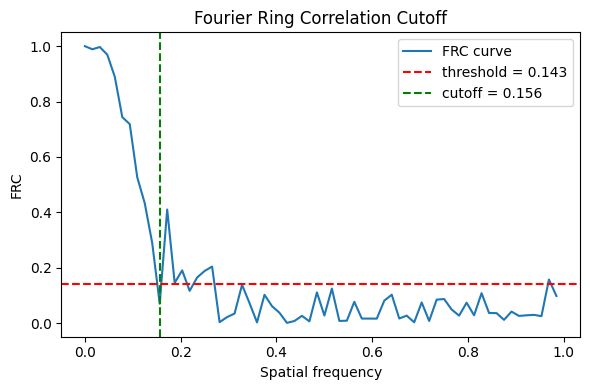

In [ ]:
def test_frc():
    """
    Simple sanity test for FRC + FRCLoss.
    """

    # ---------------------------------
    # 1. Create synthetic images
    # ---------------------------------
    size = 128

    x = torch.linspace(-1, 1, size)
    y = torch.linspace(-1, 1, size)
    xx, yy = torch.meshgrid(x, y, indexing="xy")

    # Base image: smooth Gaussian
    img1 = torch.exp(-(xx**2 + yy**2))

    # Slightly degraded version (blur + noise)
    noise = 0.05 * torch.randn_like(img1)
    img2 = torch.exp(-(xx**2 + yy**2) * 1.2) + noise

    img1 = img1.float()
    img2 = img2.float()

    # ---------------------------------
    # 2. Compute FRC
    # ---------------------------------
    frc, freq = get_fourier_ring_correlations(img1, img2)

    print(1.0 - frc.mean())

    # ---------------------------------
    # 3. Compute loss
    # ---------------------------------
    loss = FRCLoss(img1, img2)

    print(f"FRC Loss: {loss.item():.4f}")

    # ---------------------------------
    # 4. Plot
    # ---------------------------------
    FCRCutoff(img1, img2, threshold=1/7, plot=True)


# Run test
test_frc()

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()